# 🌿 VedaVision — Module 2
# Notebook 03 — Augmentation (Post-Preprocessing)
### Input: preprocessed/ → Output: augmented_final/

---

**Input**  : `dataset/preprocessed/species_name/top/*.jpg`  
             `dataset/preprocessed/species_name/bottom/*.jpg`

**Output** : `dataset/augmented_final/species_name/top/*.jpg`  
             `dataset/augmented_final/species_name/bottom/*.jpg`

---

### Why augment AFTER preprocessing?
```
✅ Background already removed — augmentation only affects the leaf
✅ No shadow in augmented variants
✅ Consistent clean base images
✅ Preprocess once → multiply by 9 variants
```

### Safe augmentations for preprocessed images:
```
✅ Flips & Rotations  — no pixel value change
✅ Zoom crop          — still on clean image
✅ Gentle brightness  — ±10% only (not heavy)
❌ Heavy noise        — already denoised!
❌ Heavy contrast     — CLAHE already done!
❌ Colour jitter      — colour normalization done!
```
---

## Cell 1 — Install Libraries

In [1]:
!pip install opencv-python-headless matplotlib numpy tqdm -q
print('✅ Libraries installed!')

✅ Libraries installed!


## Cell 2 — Import Libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from glob import glob
from tqdm import tqdm
from google.colab import drive

print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 3 — Mount Drive & Configure Paths
**Only change things in this cell**

In [3]:
drive.mount('/content/drive')

# ============================================================
# ✏️  UPDATE THESE PATHS — match your preprocessing notebook
# ============================================================
PREPROCESSED_PATH  = '/content/drive/MyDrive/VedaVision/dataset/preprocessed6'
AUGMENTED_FINAL    = '/content/drive/MyDrive/VedaVision/dataset/augmented_final'
LOGS_PATH          = '/content/drive/MyDrive/VedaVision/dataset/logs'

VIEWS              = ['top', 'bottom']   # must match preprocessing notebook
IMG_EXTENSIONS     = ('.jpg', '.jpeg', '.png')
# ============================================================

os.makedirs(AUGMENTED_FINAL, exist_ok=True)
os.makedirs(LOGS_PATH,       exist_ok=True)

# Get all species (skip hidden folders)
species_list = sorted([
    d for d in os.listdir(PREPROCESSED_PATH)
    if os.path.isdir(os.path.join(PREPROCESSED_PATH, d))
    and not d.startswith('.')
])

print(f'✅ Drive mounted!')
print(f'📁 Input  (Preprocessed) : {PREPROCESSED_PATH}')
print(f'📁 Output (Aug Final)    : {AUGMENTED_FINAL}')
print(f'🌿 Species found         : {species_list}')
print(f'👁️  Views                 : {VIEWS}')

Mounted at /content/drive
✅ Drive mounted!
📁 Input  (Preprocessed) : /content/drive/MyDrive/VedaVision/dataset/preprocessed6
📁 Output (Aug Final)    : /content/drive/MyDrive/VedaVision/dataset/augmented_final
🌿 Species found         : ['Rathu_Koboleela', 'Sudu_Koboleela']
👁️  Views                 : ['top', 'bottom']


## Cell 4 — Preview Preprocessed Input Images

/tmp/ipykernel_2438/4059209302.py:42: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2438/4059209302.py:43: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/03_preprocessed_input_samples.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


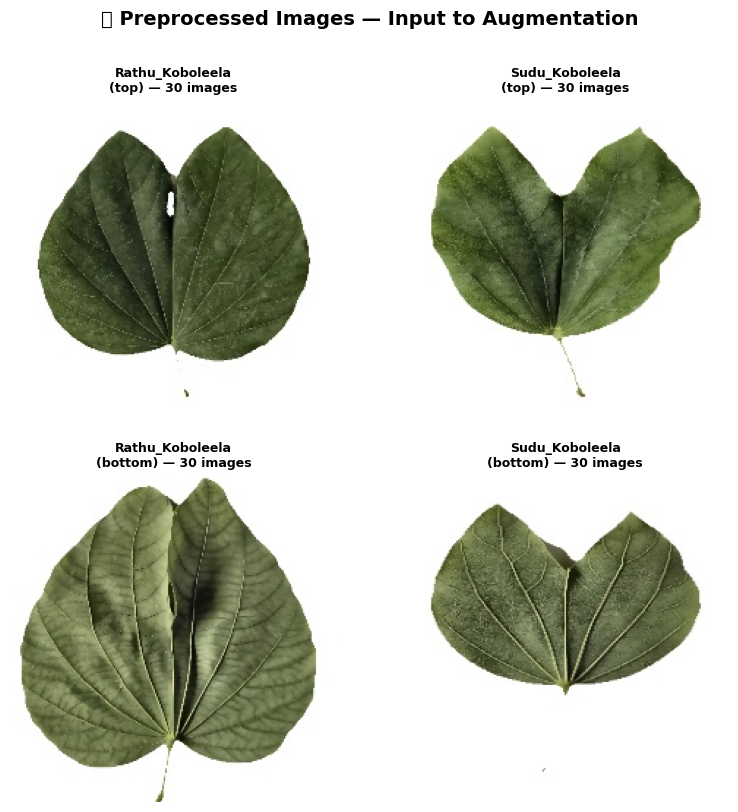

✅ Input preview complete!


In [4]:
def get_images(base_path, species, view):
    """Get all images for a species/view combination."""
    return (
        glob(os.path.join(base_path, species, view, '*.jpg'))  +
        glob(os.path.join(base_path, species, view, '*.jpeg')) +
        glob(os.path.join(base_path, species, view, '*.png'))
    )

def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Show one sample per species per view
n_species = len(species_list)
n_views   = len(VIEWS)
fig, axes = plt.subplots(n_views, n_species,
                         figsize=(n_species * 4, n_views * 4))

if n_species == 1:
    axes = axes.reshape(n_views, 1)
if n_views == 1:
    axes = axes.reshape(1, n_species)

for row, view in enumerate(VIEWS):
    for col, species in enumerate(species_list):
        imgs = get_images(PREPROCESSED_PATH, species, view)
        ax   = axes[row][col]
        if imgs:
            img = cv2.imread(random.choice(imgs))
            ax.imshow(bgr2rgb(img))
            total = len(imgs)
            ax.set_title(
                f'{species}\n({view}) — {total} images',
                fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'{species}/{view}\n⚠️ No images',
                         fontsize=9, color='red')
        ax.axis('off')

plt.suptitle('📷 Preprocessed Images — Input to Augmentation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/03_preprocessed_input_samples.png',
            bbox_inches='tight', dpi=120)
plt.show()
print('✅ Input preview complete!')

## Cell 5 — Define Safe Augmentation Functions
### Only augmentations that are safe for preprocessed images

In [5]:
# ============================================================
# SAFE AUGMENTATION FUNCTIONS FOR PREPROCESSED IMAGES
# ============================================================

def aug_original(img):
    """Keep original — no change."""
    return img.copy()


def aug_flip_horizontal(img):
    """
    Mirror left-right.
    Safe: no pixel value change.
    Models leaf facing other direction.
    """
    return cv2.flip(img, 1)


def aug_flip_vertical(img):
    """
    Mirror top-bottom.
    Safe: no pixel value change.
    """
    return cv2.flip(img, 0)


def aug_rotate_90(img):
    """
    Rotate 90° clockwise.
    Safe: no pixel value change.
    """
    return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)


def aug_rotate_180(img):
    """
    Rotate 180°.
    Safe: no pixel value change.
    """
    return cv2.rotate(img, cv2.ROTATE_180)


def aug_rotate_270(img):
    """
    Rotate 270° clockwise.
    Safe: no pixel value change.
    """
    return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)


def aug_zoom_crop(img):
    """
    Zoom in — crop center 80% and resize back to 224×224.
    Safe: simulates leaf closer to camera.
    White background stays white after resize.
    """
    h, w    = img.shape[:2]
    margin  = int(h * 0.10)  # 10% from each side = 80% crop
    cropped = img[margin:h-margin, margin:w-margin]
    return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_AREA)


def aug_brightness_up(img):
    """
    Gentle brightness increase (+10% only).
    Safe: white background stays white (255 is clamped).
    Simulates slightly brighter lighting.
    NOTE: Heavy brightness was removed — CLAHE already done!
    """
    result = cv2.convertScaleAbs(img, alpha=1.10, beta=10)
    # Ensure white background stays white
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bg     = (gray > 240).astype(np.uint8)
    for c in range(3):
        result[:,:,c] = np.where(bg > 0, 255, result[:,:,c])
    return result


def aug_brightness_down(img):
    """
    Gentle brightness decrease (-10% only).
    Safe: simulates slightly dimmer lighting.
    White background stays white.
    NOTE: Heavy brightness removed — preprocessing already normalised!
    """
    result = cv2.convertScaleAbs(img, alpha=0.90, beta=-10)
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bg     = (gray > 240).astype(np.uint8)
    for c in range(3):
        result[:,:,c] = np.where(bg > 0, 255, result[:,:,c])
    return result


# ── All augmentations as ordered list ─────────────────────
AUGMENTATIONS = [
    ('original',     aug_original),
    ('flip_h',       aug_flip_horizontal),
    ('flip_v',       aug_flip_vertical),
    ('rot_90',       aug_rotate_90),
    ('rot_180',      aug_rotate_180),
    ('rot_270',      aug_rotate_270),
    ('zoom',         aug_zoom_crop),
    ('bright_up',    aug_brightness_up),
    ('bright_down',  aug_brightness_down),
]

print(f'✅ {len(AUGMENTATIONS)} safe augmentation functions defined!')
print()
print('   Augmentation      Reason safe for preprocessed images')
print('   ──────────────────────────────────────────────────────')
print('   original        → base image kept ✅')
print('   flip_h          → no pixel value change ✅')
print('   flip_v          → no pixel value change ✅')
print('   rot_90          → no pixel value change ✅')
print('   rot_180         → no pixel value change ✅')
print('   rot_270         → no pixel value change ✅')
print('   zoom            → background stays white ✅')
print('   bright_up       → gentle +10% only, bg preserved ✅')
print('   bright_down     → gentle -10% only, bg preserved ✅')
print()
print('   ❌ Removed: heavy brightness, gaussian noise,')
print('      colour jitter, heavy contrast')
print('      (preprocessing already handled these!)')

✅ 9 safe augmentation functions defined!

   Augmentation      Reason safe for preprocessed images
   ──────────────────────────────────────────────────────
   original        → base image kept ✅
   flip_h          → no pixel value change ✅
   flip_v          → no pixel value change ✅
   rot_90          → no pixel value change ✅
   rot_180         → no pixel value change ✅
   rot_270         → no pixel value change ✅
   zoom            → background stays white ✅
   bright_up       → gentle +10% only, bg preserved ✅
   bright_down     → gentle -10% only, bg preserved ✅

   ❌ Removed: heavy brightness, gaussian noise,
      colour jitter, heavy contrast
      (preprocessing already handled these!)


## Cell 6 — Preview All Augmentations on ONE Image
### Shows all 9 variants in one row — check before running full dataset

/tmp/ipykernel_2438/711321758.py:31: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2438/711321758.py:32: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/03_augmentation_all_variants.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


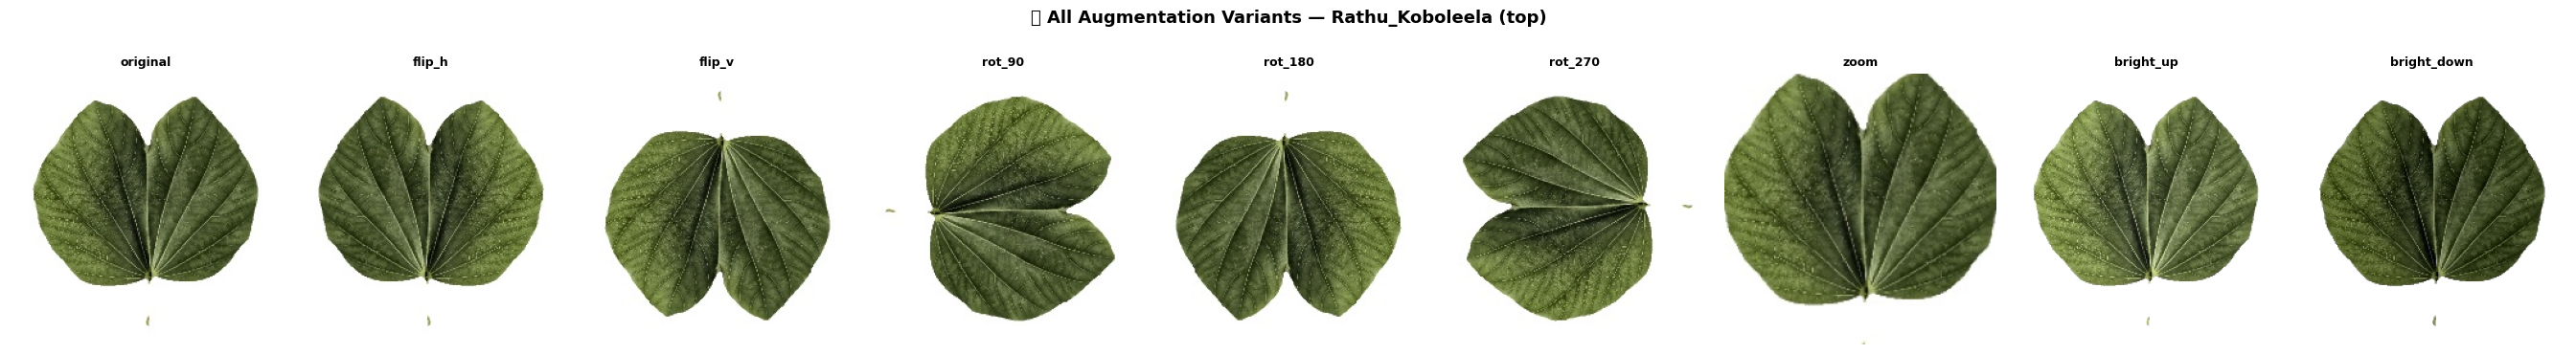

✅ Preview saved!
   1 preprocessed image → 9 augmented variants
   If results look good → run Cell 7 (step-by-step)
   Then run Cell 8 (full dataset)


In [6]:
# Pick one sample from first species first view
sample_species = species_list[0]
sample_view    = VIEWS[0]
sample_imgs    = get_images(PREPROCESSED_PATH, sample_species, sample_view)

if not sample_imgs:
    print(f'⚠️  No images found for {sample_species}/{sample_view}')
    print(f'   Check PREPROCESSED_PATH in Cell 3!')
else:
    sample_bgr = cv2.imread(random.choice(sample_imgs))

    # Apply all augmentations
    results = []
    for aug_name, aug_fn in AUGMENTATIONS:
        aug_img = aug_fn(sample_bgr)
        results.append((aug_name, aug_img))

    # ── Display all 9 in ONE ROW ──────────────────────────
    n   = len(results)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))
    fig.suptitle(
        f'🌿 All Augmentation Variants — {sample_species} ({sample_view})',
        fontsize=13, fontweight='bold'
    )

    for ax, (name, img) in zip(axes, results):
        ax.imshow(bgr2rgb(img))
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{LOGS_PATH}/03_augmentation_all_variants.png',
                bbox_inches='tight', dpi=120)
    plt.show()
    print(f'✅ Preview saved!')
    print(f'   1 preprocessed image → {n} augmented variants')
    print(f'   If results look good → run Cell 7 (step-by-step)')
    print(f'   Then run Cell 8 (full dataset)')

## Cell 7 — Step by Step Preview
### Shows Original → Each Augmentation one by one

In [7]:
print('📸 Step-by-step augmentation preview:\n')
original_rgb = bgr2rgb(sample_bgr)

for i, (aug_name, aug_fn) in enumerate(AUGMENTATIONS[1:], 1):
    aug_img     = aug_fn(sample_bgr)
    aug_img_rgb = bgr2rgb(aug_img)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f'Augmentation {i} of {len(AUGMENTATIONS)-1}: {aug_name}',
        fontsize=13, fontweight='bold'
    )
    axes[0].imshow(original_rgb)
    axes[0].set_title('Original (Preprocessed)', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(aug_img_rgb)
    axes[1].set_title(f'After: {aug_name}', fontsize=11)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

print('✅ Step-by-step preview complete!')
print('   If all look good → run Cell 8 for full dataset')

Output hidden; open in https://colab.research.google.com to view.

## Cell 8 — Run Augmentation on Full Preprocessed Dataset
⚠️ Only run after Cell 6 & 7 look correct

In [8]:
print('🔄 Running augmentation on full preprocessed dataset...')
print(f'   Input : {PREPROCESSED_PATH}')
print(f'   Output: {AUGMENTED_FINAL}')
print(f'   Each image → {len(AUGMENTATIONS)} variants')
print('=' * 65)

total_input  = 0
total_saved  = 0
total_failed = 0
summary      = {}

for species in species_list:
    for view in VIEWS:
        input_path  = os.path.join(PREPROCESSED_PATH,  species, view)
        output_path = os.path.join(AUGMENTED_FINAL, species, view)
        os.makedirs(output_path, exist_ok=True)

        imgs = get_images(PREPROCESSED_PATH, species, view)

        if not imgs:
            print(f'  ⚠️  No images: {species}/{view}')
            continue

        total_input += len(imgs)
        ok = 0

        for img_path in tqdm(imgs,
                             desc=f'  {species}/{view}'):
            img = cv2.imread(img_path)
            if img is None:
                total_failed += 1
                continue

            base = os.path.splitext(
                   os.path.basename(img_path))[0]

            for aug_name, aug_fn in AUGMENTATIONS:
                try:
                    aug_img  = aug_fn(img)
                    out_name = f'{base}_{aug_name}.jpg'
                    out_path = os.path.join(output_path, out_name)
                    cv2.imwrite(out_path, aug_img,
                                [cv2.IMWRITE_JPEG_QUALITY, 95])
                    ok           += 1
                    total_saved  += 1
                except Exception as e:
                    total_failed += 1

        key = f'{species}/{view}'
        summary[key] = {
            'input'  : len(imgs),
            'output' : ok
        }
        print(f'  ✅ {species}/{view}: '
              f'{len(imgs)} → {ok} images saved')

print('=' * 65)
print(f'✅ Augmentation complete!')
print(f'   Input images  : {total_input}')
print(f'   Output images : {total_saved}')
print(f'   Failed        : {total_failed}')
print(f'   Multiplier    : ×{len(AUGMENTATIONS)}')
print(f'   Saved to      : {AUGMENTED_FINAL}')

🔄 Running augmentation on full preprocessed dataset...
   Input : /content/drive/MyDrive/VedaVision/dataset/preprocessed6
   Output: /content/drive/MyDrive/VedaVision/dataset/augmented_final
   Each image → 9 variants


  Rathu_Koboleela/top: 100%|██████████| 30/30 [00:14<00:00,  2.04it/s]


  ✅ Rathu_Koboleela/top: 30 → 270 images saved


  Rathu_Koboleela/bottom: 100%|██████████| 30/30 [00:11<00:00,  2.63it/s]


  ✅ Rathu_Koboleela/bottom: 30 → 270 images saved


  Sudu_Koboleela/top: 100%|██████████| 30/30 [00:10<00:00,  2.97it/s]


  ✅ Sudu_Koboleela/top: 30 → 270 images saved


  Sudu_Koboleela/bottom: 100%|██████████| 30/30 [00:13<00:00,  2.21it/s]

  ✅ Sudu_Koboleela/bottom: 30 → 270 images saved
✅ Augmentation complete!
   Input images  : 120
   Output images : 1080
   Failed        : 0
   Multiplier    : ×9
   Saved to      : /content/drive/MyDrive/VedaVision/dataset/augmented_final


## Cell 9 — Preview Augmented Final Results Per Species

👁️  Augmented final output samples:



/tmp/ipykernel_3736/1487336202.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


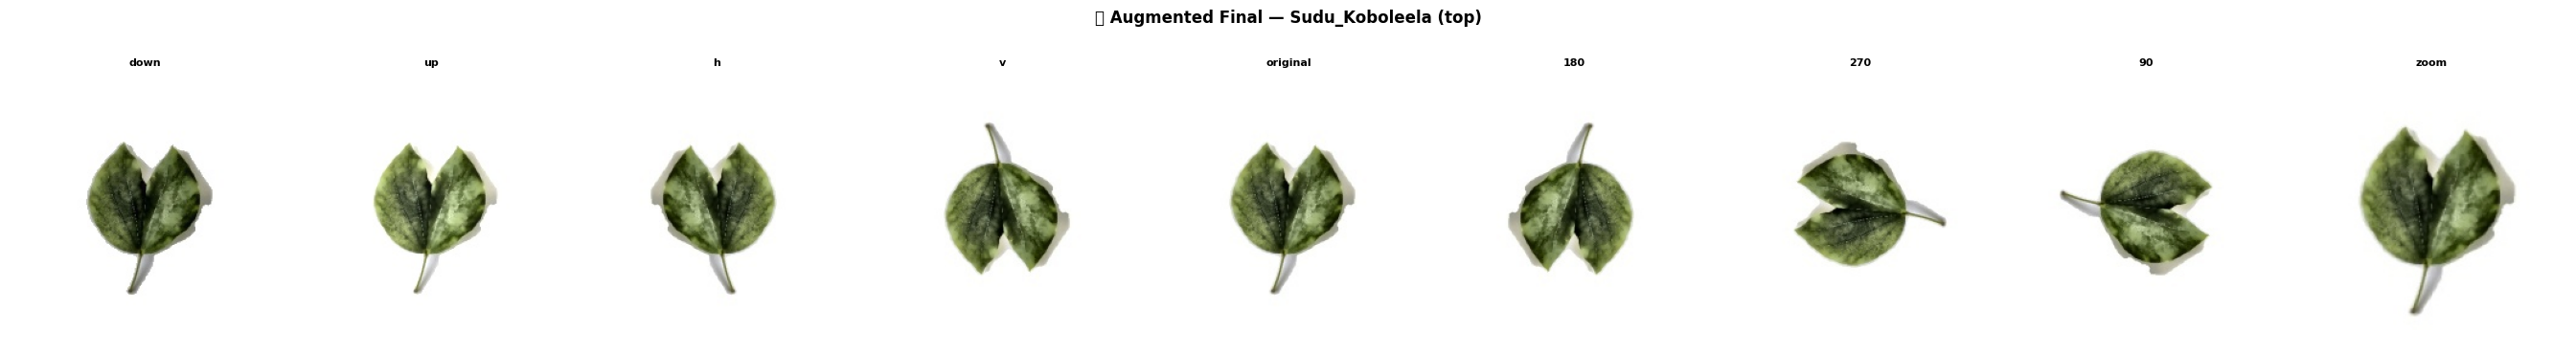

   Sudu_Koboleela/top: 522 augmented images ✅


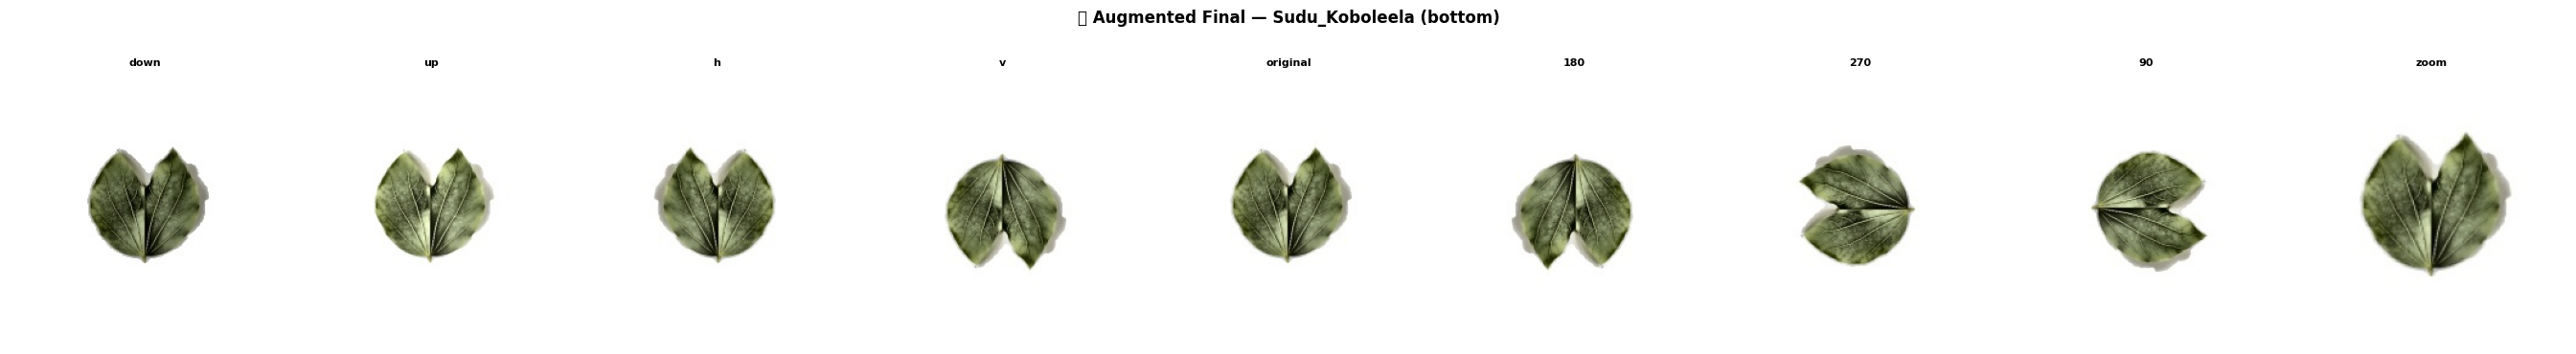

   Sudu_Koboleela/bottom: 522 augmented images ✅


In [ ]:
print('👁️  Augmented final output samples:\n')

for species in species_list:
    for view in VIEWS:
        cls_dir  = os.path.join(AUGMENTED_FINAL, species, view)
        all_imgs = sorted(
            glob(os.path.join(cls_dir, '*.jpg')))[:9]

        if not all_imgs:
            print(f'  ⚠️  No augmented images: {species}/{view}')
            continue

        n   = len(all_imgs)
        fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))
        fig.suptitle(
            f'✅ Augmented Final — {species} ({view})',
            fontsize=12, fontweight='bold'
        )
        if n == 1:
            axes = [axes]

        for ax, fpath in zip(axes, all_imgs):
            img  = cv2.imread(fpath)
            name = os.path.basename(fpath)
            # Get just the augmentation name from filename
            aug_label = name.split('_')[-1].replace('.jpg','')
            ax.imshow(bgr2rgb(img))
            ax.set_title(aug_label, fontsize=8,
                         fontweight='bold')
            ax.axis('off')

        plt.tight_layout()
        plt.show()

        total = len(glob(os.path.join(cls_dir, '*.jpg')))
        print(f'   {species}/{view}: {total} augmented images ✅')

## Cell 10 — Final Dataset Summary Chart

📊 FINAL DATASET SUMMARY
Species/View                         Preprocessed Augmented Final
----------------------------------------------------------------------
Sudu_Koboleela/top                             58             522
Sudu_Koboleela/bottom                          58             522
TOTAL                                         116            1044
   Multiplication factor: ×9


/tmp/ipykernel_3736/4015503151.py:56: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3736/4015503151.py:57: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/03_augmented_final_summary.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


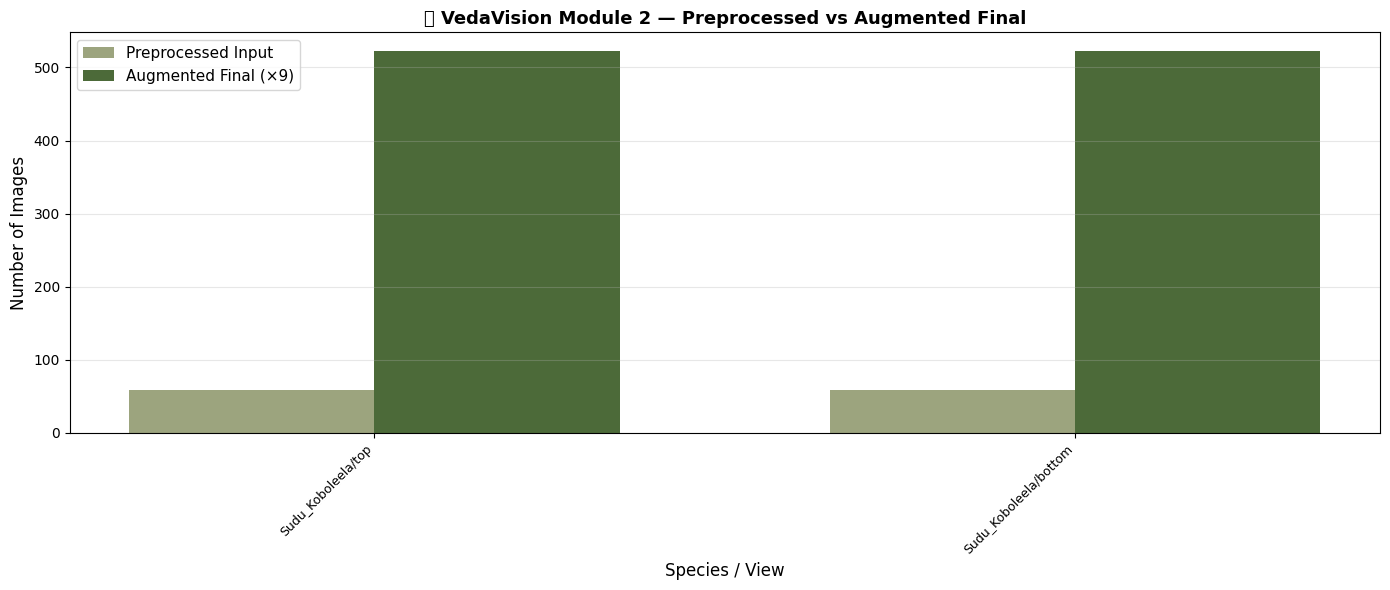


✅ Summary chart saved!
📋 Next step: Run 04_Feature_Extraction.ipynb
   Input: /content/drive/MyDrive/VedaVision/dataset/augmented_final


In [ ]:
import numpy as np

print('📊 FINAL DATASET SUMMARY')
print('=' * 70)
print(f'{"Species/View":<35} {"Preprocessed":>13} {"Augmented Final":>15}')
print('-' * 70)

total_pre  = 0
total_aug  = 0
s_labels   = []
pre_counts = []
aug_counts = []

for species in species_list:
    for view in VIEWS:
        pre = len(get_images(PREPROCESSED_PATH, species, view))
        aug = len(glob(os.path.join(
            AUGMENTED_FINAL, species, view, '*.jpg')))

        total_pre += pre
        total_aug += aug
        label = f'{species[:14]}/{view}'
        s_labels.append(label)
        pre_counts.append(pre)
        aug_counts.append(aug)
        print(f'{species}/{view:<20} {pre:>13} {aug:>15}')

print('=' * 70)
print(f'{"TOTAL":<35} {total_pre:>13} {total_aug:>15}')
print(f'   Multiplication factor: ×{len(AUGMENTATIONS)}')

# ── Bar chart ─────────────────────────────────────────────
x     = np.arange(len(s_labels))
width = 0.35

fig, ax = plt.subplots(
    figsize=(max(14, len(s_labels) * 2), 6))
ax.bar(x - width/2, pre_counts, width,
       label='Preprocessed Input',
       color='#8B9467', alpha=0.85)
ax.bar(x + width/2, aug_counts, width,
       label=f'Augmented Final (×{len(AUGMENTATIONS)})',
       color='#2D5016', alpha=0.85)

ax.set_xlabel('Species / View', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title(
    '🌿 VedaVision Module 2 — Preprocessed vs Augmented Final',
    fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(s_labels,
                   rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/03_augmented_final_summary.png',
            bbox_inches='tight', dpi=150)
plt.show()

print(f'\n✅ Summary chart saved!')
print(f'📋 Next step: Run 04_Feature_Extraction.ipynb')
print(f'   Input: {AUGMENTED_FINAL}')